# Análisis clásico y longitudinal del ensayo

**Experimento:** momento de aplicación de nitrógeno en *Festuca arundinacea* Schreb. cv. Rizar, en los sectores de secano y riego suplementario.

Este cuaderno tiene dos objetivos deliberadamente separados:

1. **Calcular los análisis por fecha y sector** a partir de las mediciones primitivas del libro de Excel: ANOVA de bloques completos al azar, comparación M1–M5, comparación complementaria M0–M5, Tukey cuando corresponde, análisis conjunto descriptivo entre sectores, sensibilidad del dato faltante y correlaciones exploratorias.
2. **Realizar la inferencia temporal principal** usando conjuntamente las tres mediciones posteriores al tratamiento mediante un modelo mixto con intercepto aleatorio por parcela.

Los ANOVA por fecha se conservan como descripción y seguimiento. Para los desenlaces repetidos, el modelo longitudinal es la inferencia principal porque respeta que las tres fechas pertenecen a las mismas parcelas. La conciliación con valores publicados en la tesis se realiza manualmente fuera del notebook.

## Resumen ejecutivo

El cuaderno:

- reconstruye **144 observaciones parcela-fecha** y **48 observaciones de cosecha**;
- conserva el dato faltante de N de M1–R4–secano–16/09 como ausente en el análisis principal;
- recalcula el INN principal con la curva `3.93 × W^-0.42` y mantiene la curva histórica como sensibilidad;
- calcula los resultados directamente desde el libro, sin valores objetivo copiados de la tesis;
- separa siempre la pregunta de **momento de aplicación** (M1–M5) de la pregunta complementaria de **N experimental adicional** (M0 frente a M1–M5);
- trata los dos sectores como contextos fijos observados, **no** como repeticiones aleatorias de un tratamiento de riego;
- no usa las mediciones de junio como covariables por parcela: el libro contiene una caracterización general por sector/bloque, no una línea basal para cada una de las 48 parcelas;
- deja visible una política de sensibilidad para los registros de materia seca 150 y 152, pero usa por defecto los valores registrados;
- genera y exporta un conjunto reducido de **figuras listas para tesis**, distinguiendo las recomendadas para el cuerpo principal de las apropiadas para un anexo;
- separa una jerarquía inferencial explícita: rendimiento primario, biomasa y concentración de N secundarias, variables derivadas de apoyo y análisis exploratorios;
- calibra por bootstrap paramétrico la interacción calendario × fecha de biomasa y concentración de N, y controla FDR dentro de las familias secundarias y de apoyo;
- resume EAN y productividad aparente del agua de forma descriptiva, sin volver a probar transformaciones deterministas del rendimiento como desenlaces independientes.

## 1. Configuración

Entorno reproducible recomendado:

```bash
uv sync --frozen
uv run --frozen jupyter lab festuca_estudio_longitudinal.ipynb
```

El libro debe estar en `sources/Datos_Ema_Serrana_INN.xlsx`. Como alternativa, también puede estar en `/mnt/data`.
Las figuras usan el tema Seaborn compartido por el paquete `festuca_analysis`; no requieren un archivo de estilo externo.

`DRY_MATTER_POLICY` controla exclusivamente los dos registros finales señalados en la auditoría:

- `"recorded"`: usa `%MS` tal como figura en el libro; **opción principal**;
- `"ratio"`: sustituye esos dos `%MS` por `100 × peso seco / peso verde de submuestra`;
- `"exclude"`: deja esos dos valores de biomasa como ausentes.

La opción `ratio` es una sensibilidad diagnóstica, no una corrección afirmada: primero deben verificarse los registros originales.

Las figuras seleccionadas se exportan, por defecto, como PNG de 300 dpi y como PDF vectorial en `festuca_thesis_figures/`.

Las celdas ejecutables solo invocan funciones del paquete `festuca_analysis`; la implementación se encuentra en `src/`.

In [1]:
from festuca_analysis import LongitudinalNotebook

analysis = LongitudinalNotebook()
analysis.configuration()


Python 3.12.13
pandas 2.3.3
numpy 2.4.6
scipy 1.18.0
statsmodels 0.14.6


## 2. Carga y reconstrucción de los datos

Las variables derivadas se vuelven a calcular a partir de mediciones primitivas. El libro original no se modifica.

In [2]:
analysis.load_data()


Libro: /Users/agustinsellanes/Repos/festuca_probabilistic_analysis/sources/Datos_Ema_Serrana_INN.xlsx
Política de materia seca: recorded


,check,observed,expected,passes
0,filas longitudinales,144.0000,144.0000,True
1,parcelas longitudinales,48.0000,48.0000,True
2,fechas por parcela,3.0000,3.0000,True
3,filas de cosecha,48.0000,48.0000,True
4,parcelas de cosecha,48.0000,48.0000,True
5,duplicados parcela-fecha,0.0000,0.0000,True
6,duplicados de cosecha,0.0000,0.0000,True
7,resultados N faltantes,1.0000,1.0000,True
8,registros %MS señalados,2.0000,2.0000,True
9,máxima diferencia PMS recalculado-libro,0.0000,0.0000,True


### 2.1 Registros de materia seca señalados

Se muestran para que cualquier análisis de sensibilidad sea visible y trazable. La ejecución por defecto conserva los valores registrados.

In [3]:
analysis.flagged_dry_matter()


,sample_id,sector,block,treatment,date,dm_pct_recorded,dm_ratio_pct,biomass_kg_ha_recorded,biomass_kg_ha_used
134,152,Riego,R4,M2,2025-11-12,25.0000,15.1424,"14,822.3684","14,822.3684"
140,150,Riego,R4,M4,2025-11-12,18.2000,28.0952,"12,692.1053","12,692.1053"


### 2.2 Estado inicial: descripción, no covariable por parcela

Las observaciones de junio no están identificadas como mediciones de cada parcela M0–M5. Se resumen como caracterización descriptiva de los sectores.

In [4]:
analysis.baseline_summary()


,biomass_t_ha,tillers_m2,n_biomass_samples,n_tiller_samples
sector,,,,
Riego,3.7800,"2,307.0200",4,5
Secano,3.7600,"2,526.3200",4,5


### 2.3 Cronograma agronómico y N aplicado acumulado

La figura integra el calendario de aplicaciones con el N total aplicado acumulado en cada tratamiento. El área gris representa el manejo común (≈164 kg N ha⁻¹) y el área de color, los 200 kg N ha⁻¹ experimentales adicionales de M1–M5.


Se usan las fechas ejecutadas documentadas en la tesis, no la tabla preliminar conflictiva del libro. Las aplicaciones generales de abril (≈60 kg N ha⁻¹) y agosto (≈52 kg N ha⁻¹) se representan mediante rampas y tramos grises punteados porque su fecha exacta no está documentada; la aplicación común del 1.º de julio (≈52 kg N ha⁻¹) se muestra como un salto fechado. Las rampas expresan incertidumbre temporal, no liberación gradual. El acceso o exclusión del pastoreo antes del cierre del 1.º de julio debe corregirse en el texto de la tesis cuando se confirme con la bitácora de campo.

,treatment,first_application,second_application,extra_n_kg_ha
0,M0,NaT,NaT,0
1,M1,2025-06-12,2025-07-31,200
2,M2,2025-06-26,2025-07-31,200
3,M3,2025-07-10,2025-08-21,200
4,M4,2025-07-31,2025-09-04,200
5,M5,2025-08-21,2025-09-20,200


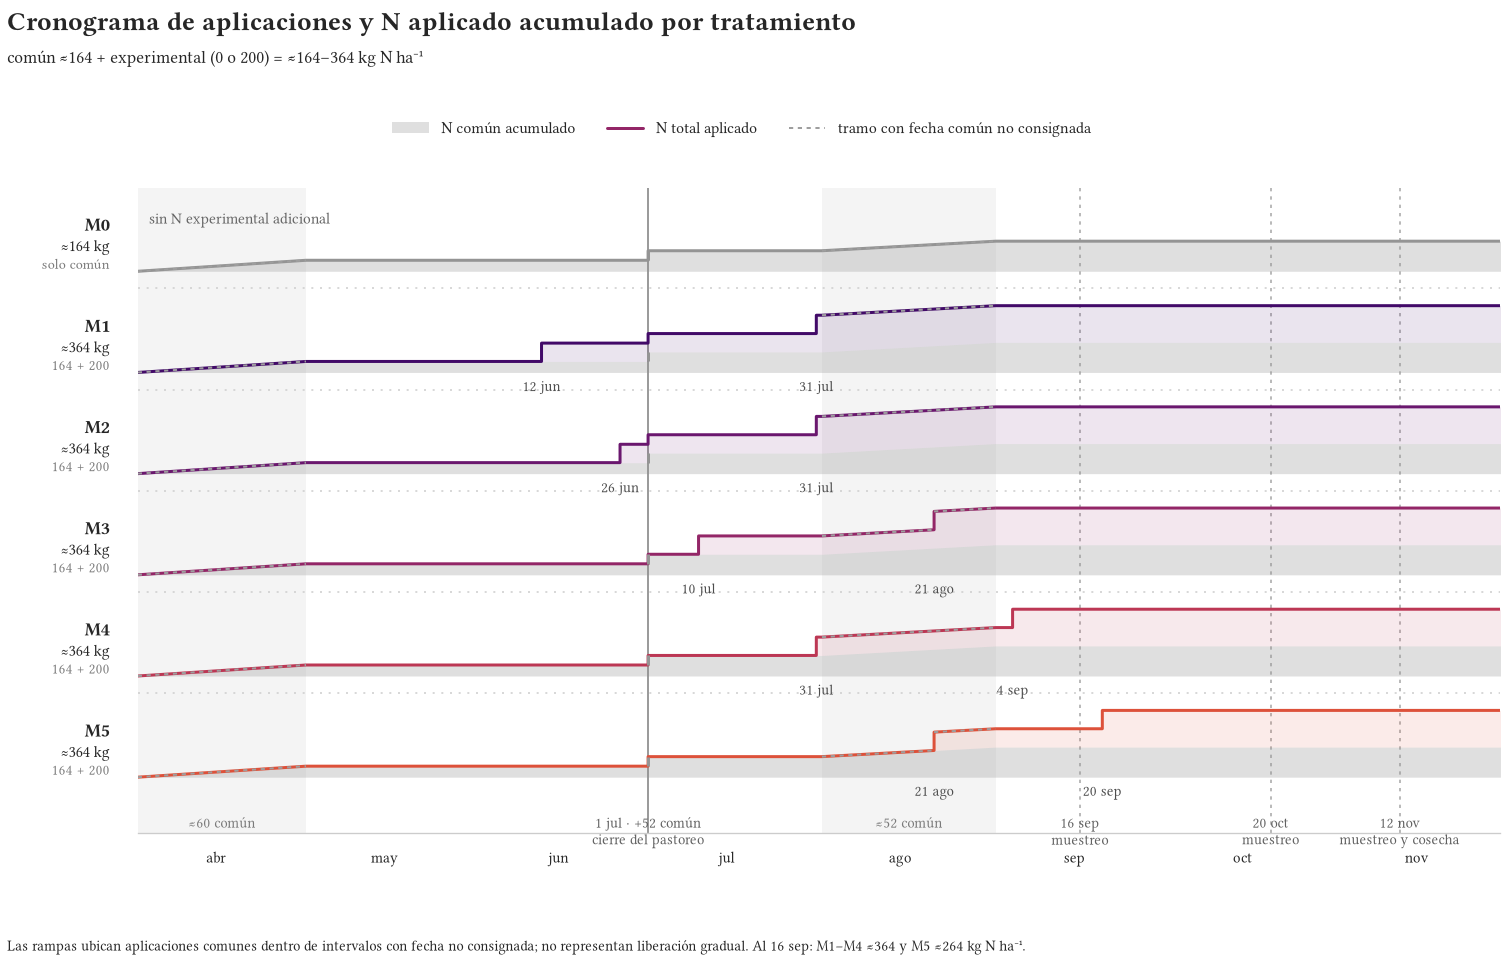

In [5]:
analysis.schedule()


### 2.4 Precipitación y riego suplementario durante el experimento

Los valores se transcriben de la tabla de caracterización hídrica de la tesis. La figura muestra **entradas brutas de agua**: precipitación común a ambos sectores y riego suplementario agregado al sector regado. No representa agua almacenada, disponible ni consumida por el cultivo; por eso no convierte la diferencia entre sectores en una estimación causal del efecto del riego.

,month,precipitation_mm,supplemental_irrigation_mm,irrigated_total_mm
0,Jun,43,15,58
1,Jul,62,0,62
2,Ago,101,0,101
3,Sep,89,30,119
4,Oct,141,90,231
5,Nov,74,30,104


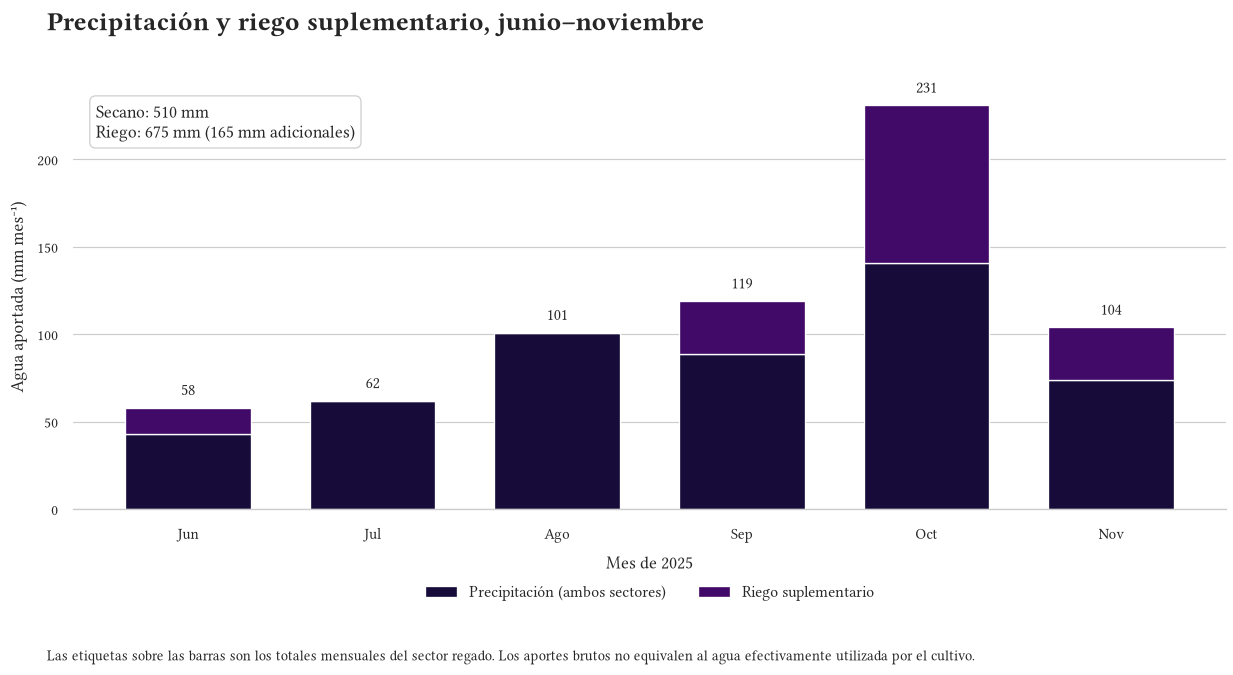

In [6]:
analysis.water_inputs()


## 3. Funciones para el análisis de bloques completos al azar

Para cada sector se ajusta:

$$
Y_{ij}=\mu+T_i+B_j+\varepsilon_{ij}.
$$

Se usa ANOVA tipo II. Las medias marginales se promedian sobre los cuatro bloques. Cuando el efecto global del tratamiento es significativo, las comparaciones de Tukey se calculan sobre diferencias entre medias marginales ajustadas.

In [7]:
analysis.rcbd_functions()


## 4. ANOVA por fecha y sector

Se analizan biomasa, concentración de N, N presente en biomasa aérea e INN por separado en cada fecha y sector mediante dos comparaciones:

- **calendario de aplicación:** M1–M5;
- **complementaria de N adicional:** M0–M5.

Estas pruebas describen fechas concretas. La inferencia temporal principal aparece en la sección 10. Los valores ajustados por Benjamini–Hochberg se calculan dentro de familias definidas antes de interpretar los resultados. La concordancia con las tablas de la tesis se revisa manualmente fuera del notebook.

In [8]:
analysis.longitudinal_anova()


,label,date_label,sector,comparison,n,p_treatment,p_bh,p_block,cv_pct
0,Biomasa aérea (kg MS ha⁻¹),16 sep,Secano,M1–M5,20,0.0015,0.0092,0.2129,25.5682
1,Biomasa aérea (kg MS ha⁻¹),16 sep,Secano,M0–M5,24,0.0005,0.0014,0.3271,26.3405
2,Biomasa aérea (kg MS ha⁻¹),16 sep,Riego,M1–M5,20,0.0333,0.0666,0.5347,14.8866
3,Biomasa aérea (kg MS ha⁻¹),16 sep,Riego,M0–M5,24,0.0015,0.0021,0.6293,14.8339
4,Biomasa aérea (kg MS ha⁻¹),20 oct,Secano,M1–M5,20,0.1725,0.2518,0.1969,16.6509
5,Biomasa aérea (kg MS ha⁻¹),20 oct,Secano,M0–M5,24,0.0008,0.0016,0.0827,16.3003
6,Biomasa aérea (kg MS ha⁻¹),20 oct,Riego,M1–M5,20,0.2021,0.2021,0.4075,15.4058
7,Biomasa aérea (kg MS ha⁻¹),20 oct,Riego,M0–M5,24,0.0002,0.0006,0.3449,15.3022
8,Biomasa aérea (kg MS ha⁻¹),12 nov,Secano,M1–M5,20,0.1017,0.2214,0.3180,13.5580
9,Biomasa aérea (kg MS ha⁻¹),12 nov,Secano,M0–M5,24,0.0290,0.0290,0.4069,16.2499


### 4.1 Medias observadas por fecha con incertidumbre

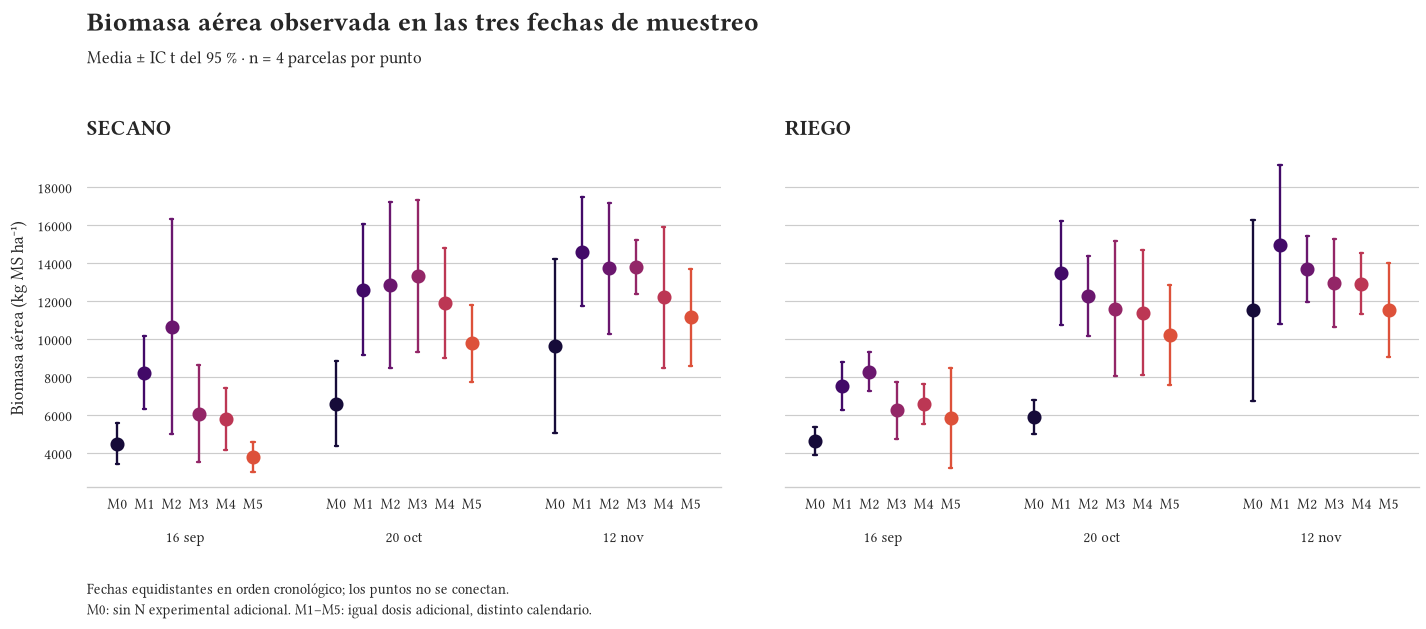

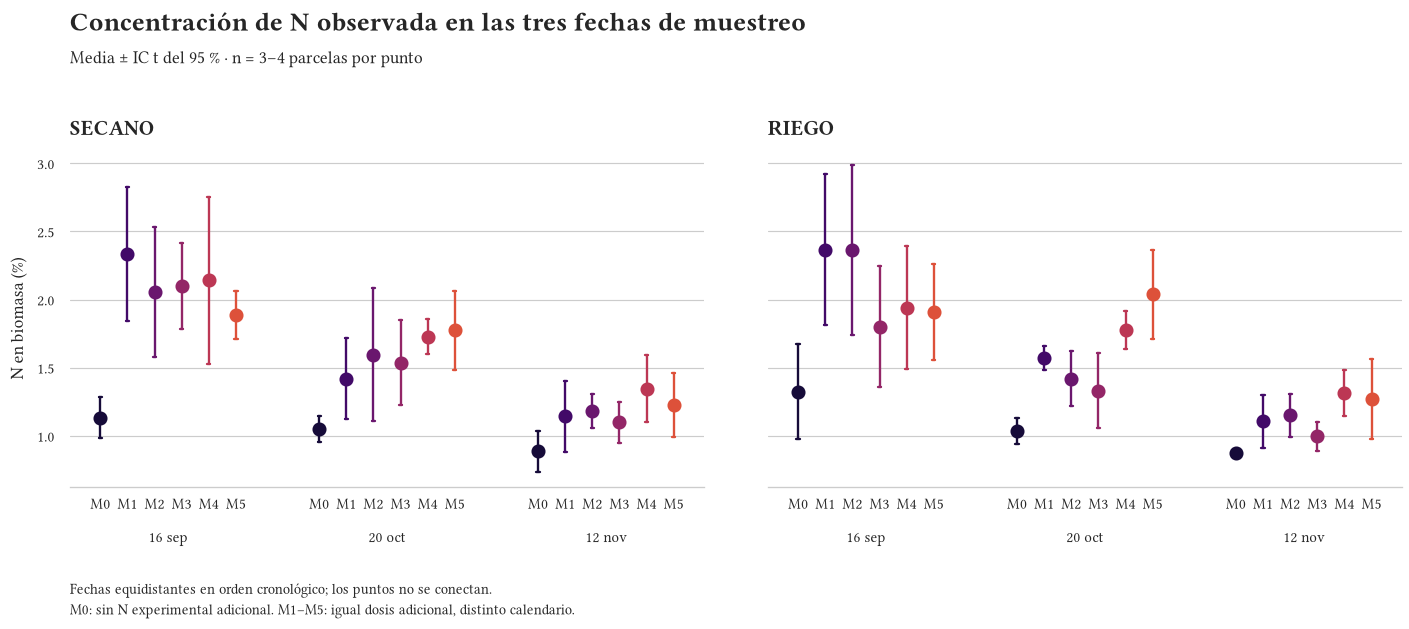

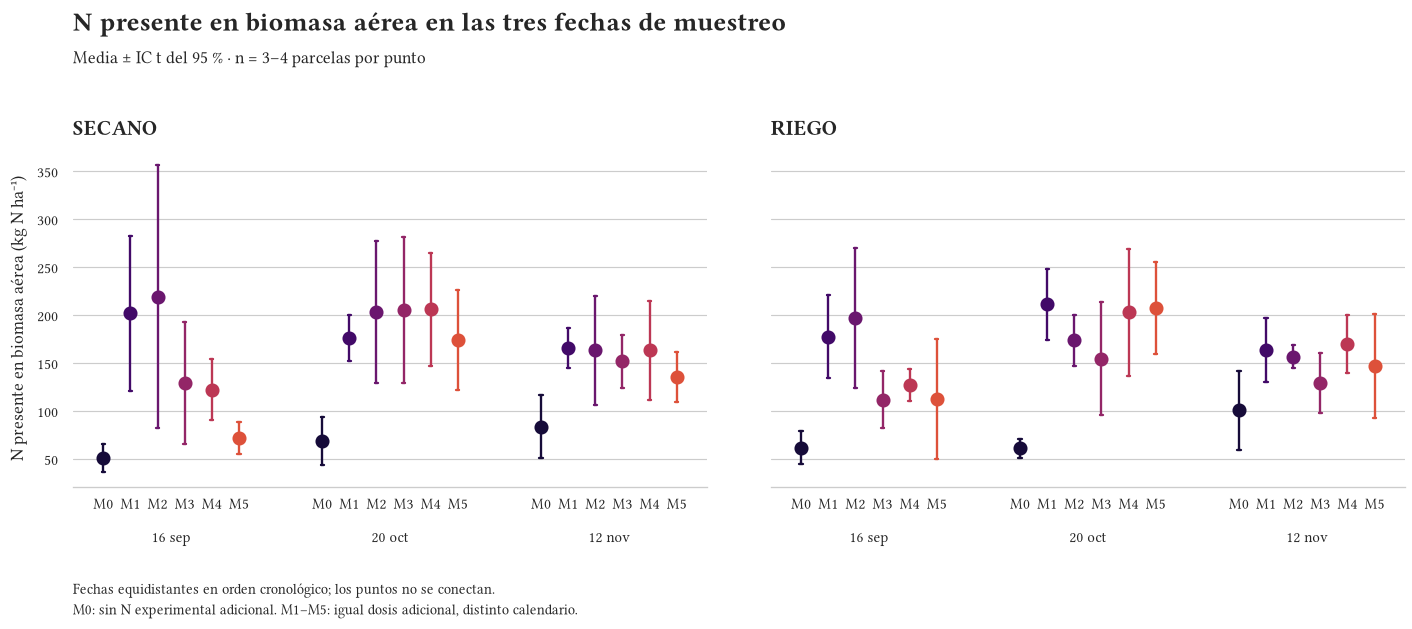

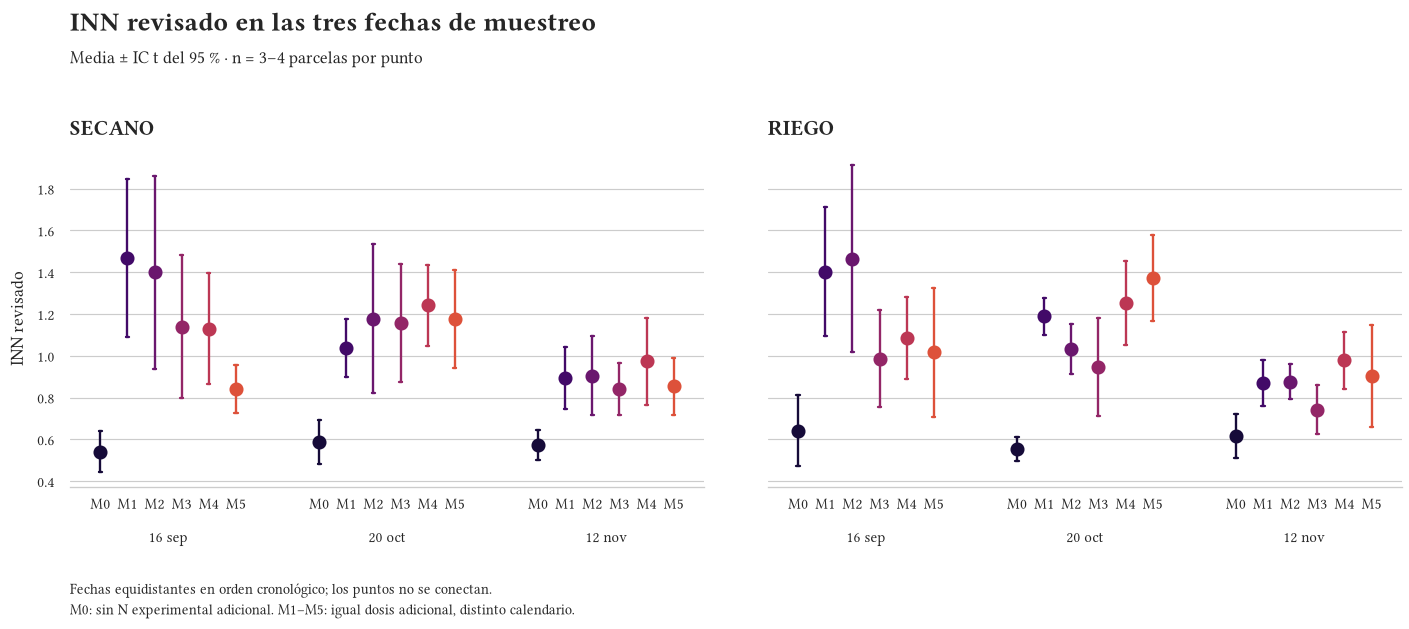

In [9]:
analysis.observed_trajectories()


## 5. Variables de cosecha y componentes del rendimiento

Las variables se reconstruyen con las mismas identidades de la tesis. El número de semillas por panoja es **estimado**, no contado de forma independiente. El rendimiento limpio M1–M5 es el desenlace primario. EAN y productividad aparente del agua se presentan solo descriptivamente porque son transformaciones deterministas del rendimiento y no aportan una prueba inferencial independiente.

In [10]:
analysis.final_outcomes()


,label,sector,comparison,inference_tier,n,p_treatment,p_bh,p_block,cv_pct
0,Panojas m⁻²,Secano,M1–M5,secundaria,20,0.0945,0.1889,0.5211,13.1158
1,Panojas m⁻²,Secano,M0–M5,secundaria,24,0.0164,0.0327,0.3685,12.4050
2,Panojas m⁻²,Riego,M1–M5,secundaria,20,0.0053,0.0107,0.9889,13.1077
3,Panojas m⁻²,Riego,M0–M5,secundaria,24,0.0085,0.0170,0.7112,14.7073
4,Semillas estimadas por panoja,Secano,M1–M5,apoyo_reconstruido,20,0.1496,0.1496,0.5610,12.2884
5,Semillas estimadas por panoja,Secano,M0–M5,apoyo_reconstruido,24,0.0007,0.0007,0.1845,13.1817
6,Semillas estimadas por panoja,Riego,M1–M5,apoyo_reconstruido,20,0.0088,0.0088,0.4843,10.9024
7,Semillas estimadas por panoja,Riego,M0–M5,apoyo_reconstruido,24,0.0001,0.0001,0.7987,12.4335
8,Peso de mil semillas (g),Secano,M1–M5,secundaria,20,0.5159,0.5159,0.6123,6.5715
9,Peso de mil semillas (g),Secano,M0–M5,secundaria,24,0.5728,0.5728,0.5221,6.1953


**EAN y productividad aparente del agua:** resumen descriptivo únicamente; no se vuelven a contar como desenlaces inferenciales independientes.

,outcome,sector,treatment,mean,sd,n,label,analysis_role
0,agronomic_efficiency,Secano,M1,3.3570,1.9770,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
1,agronomic_efficiency,Secano,M2,3.3220,1.1380,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
2,agronomic_efficiency,Secano,M3,3.2040,0.8870,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
3,agronomic_efficiency,Secano,M4,3.8400,1.0170,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
4,agronomic_efficiency,Secano,M5,2.8550,0.7670,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
5,agronomic_efficiency,Riego,M1,2.9880,0.2250,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
6,agronomic_efficiency,Riego,M2,4.0350,1.3570,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
7,agronomic_efficiency,Riego,M3,2.9820,1.3130,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
8,agronomic_efficiency,Riego,M4,3.4650,1.0070,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento
9,agronomic_efficiency,Riego,M5,2.5360,0.8080,4,Eficiencia agronómica (kg semilla kg⁻¹ N),descriptivo; transformación del rendimiento


### 5.1 Sensibilidad de los registros de materia seca 150 y 152

No se corrige ningún registro sin evidencia primaria. El análisis principal conserva el porcentaje de materia seca registrado y compara explícitamente tres políticas: **registrado**, **cociente peso seco/peso verde** y **exclusión**. Se informan tanto el valor de p como el rango de medias ajustadas para evitar que la sensibilidad se reduzca a un cambio de significancia.

In [11]:
analysis.dry_matter_sensitivity()


,policy,primary_policy,outcome,label,sector,comparison,n,p_treatment,adjusted_mean_range
0,recorded,True,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Secano,M1–M5,20,0.1017,"3,454.0526"
1,recorded,True,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Secano,M0–M5,24,0.0290,"4,971.6118"
2,recorded,True,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Riego,M1–M5,20,0.0686,"3,451.0329"
3,recorded,True,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Riego,M0–M5,24,0.2129,"3,453.2368"
4,recorded,True,q_kg_n_ha,N presente en biomasa aérea (kg N ha⁻¹),Secano,M1–M5,20,0.1912,29.8284
5,recorded,True,q_kg_n_ha,N presente en biomasa aérea (kg N ha⁻¹),Secano,M0–M5,24,0.0002,81.7971
6,recorded,True,q_kg_n_ha,N presente en biomasa aérea (kg N ha⁻¹),Riego,M1–M5,20,0.1037,40.2362
7,recorded,True,q_kg_n_ha,N presente en biomasa aérea (kg N ha⁻¹),Riego,M0–M5,24,0.0091,68.8904
8,recorded,True,nni_revised,INN revisado,Secano,M1–M5,20,0.2198,0.1323
9,recorded,True,nni_revised,INN revisado,Secano,M0–M5,24,0.0000,0.4014


### 5.2 Resumen del análisis de rendimiento

In [12]:
analysis.yield_analysis()


,sector,comparison,p_treatment,cv_pct
12,Secano,M1–M5,0.4287,10.1926
13,Secano,M0–M5,0.0000,12.0998
14,Riego,M1–M5,0.1759,12.8795
15,Riego,M0–M5,0.0001,13.4978


**Secano: medias ajustadas y grupos de Tukey, M0–M5**

,treatment,estimate,se,ci_low,ci_high,tukey_group,n
0,M0,702.6300,75.9400,540.7600,864.5000,b,4
1,M1,"1,374.0100",75.9400,"1,212.1500","1,535.8800",a,4
2,M2,"1,367.1100",75.9400,"1,205.2400","1,528.9700",a,4
3,M3,"1,343.4200",75.9400,"1,181.5500","1,505.2900",a,4
4,M4,"1,470.7200",75.9400,"1,308.8600","1,632.5900",a,4
5,M5,"1,273.6800",75.9400,"1,111.8200","1,435.5500",a,4


**Riego: medias ajustadas y grupos de Tukey, M0–M5**

,treatment,estimate,se,ci_low,ci_high,tukey_group,n
0,M0,645.3900,79.5700,475.8000,814.9900,b,4
1,M1,"1,243.0900",79.5700,"1,073.5000","1,412.6800",a,4
2,M2,"1,452.3000",79.5700,"1,282.7100","1,621.8900",a,4
3,M3,"1,241.7800",79.5700,"1,072.1900","1,411.3700",a,4
4,M4,"1,338.4900",79.5700,"1,168.9000","1,508.0800",a,4
5,M5,"1,152.6300",79.5700,983.0400,"1,322.2200",a,4


### 5.3 Rendimiento limpio: separar la respuesta al N de la comparación entre calendarios

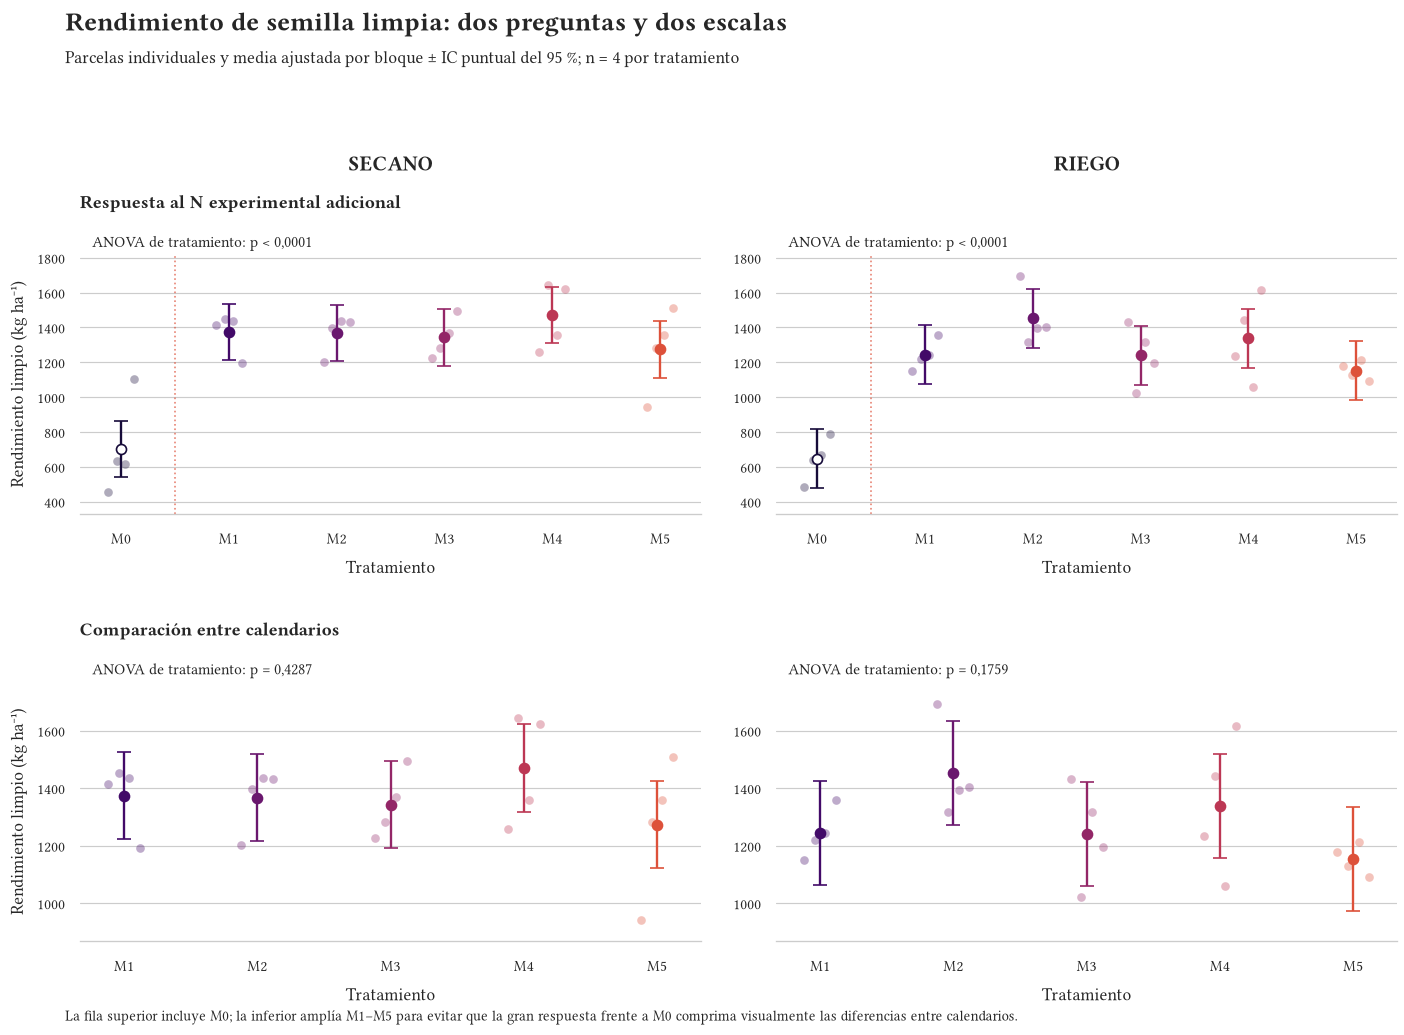

In [13]:
analysis.yield_overview()


### 5.3.1 Contrastes de rendimiento: respuesta marginal e incertidumbre

,sector,contrast,difference,ci_low,ci_high,interval_type,aggregate
0,Secano,Promedio M1–M5 − M0,663.1600,485.8400,840.4700,IC t puntual del 95 %,True
1,Secano,M1 − M2,6.9100,-306.9100,320.7300,IC simultáneo de Tukey del 95 %,False
2,Secano,M1 − M3,30.5900,-283.2300,344.4100,IC simultáneo de Tukey del 95 %,False
3,Secano,M1 − M4,-96.7100,-410.5300,217.1100,IC simultáneo de Tukey del 95 %,False
4,Secano,M1 − M5,100.3300,-213.4900,414.1500,IC simultáneo de Tukey del 95 %,False
5,Secano,M2 − M3,23.6800,-290.1300,337.5000,IC simultáneo de Tukey del 95 %,False
6,Secano,M2 − M4,-103.6200,-417.4400,210.2000,IC simultáneo de Tukey del 95 %,False
7,Secano,M2 − M5,93.4200,-220.4000,407.2400,IC simultáneo de Tukey del 95 %,False
8,Secano,M3 − M4,-127.3000,-441.1200,186.5200,IC simultáneo de Tukey del 95 %,False
9,Secano,M3 − M5,69.7400,-244.0800,383.5600,IC simultáneo de Tukey del 95 %,False


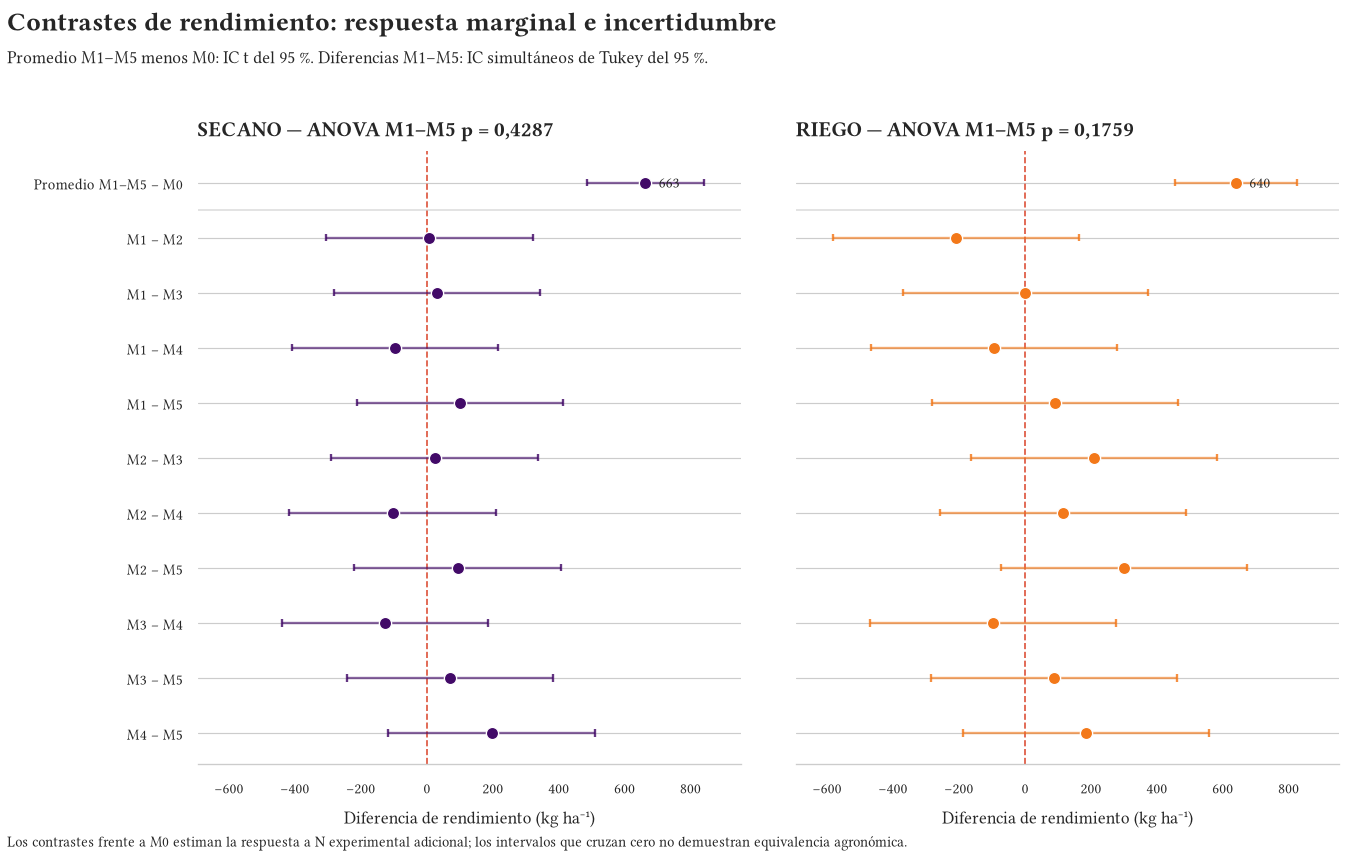

In [14]:
analysis.yield_contrasts()


### 5.4 Componentes del rendimiento: datos individuales e incertidumbre

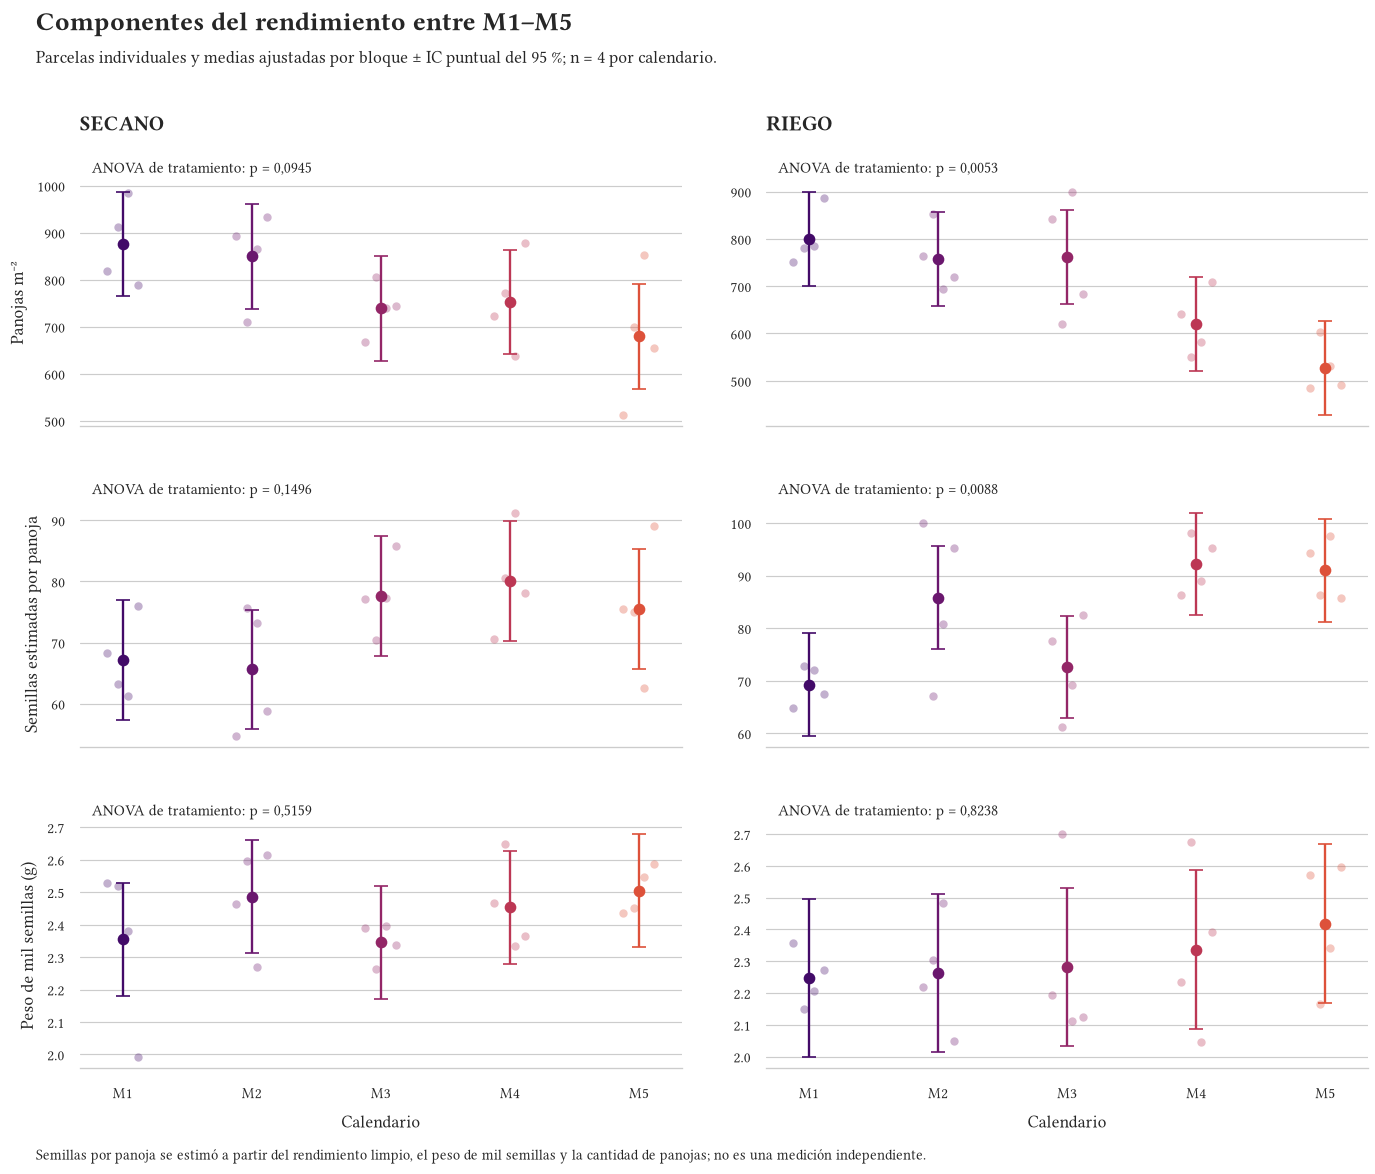

In [15]:
analysis.yield_components()


### 5.5 Relación descriptiva entre los componentes reconstruidos

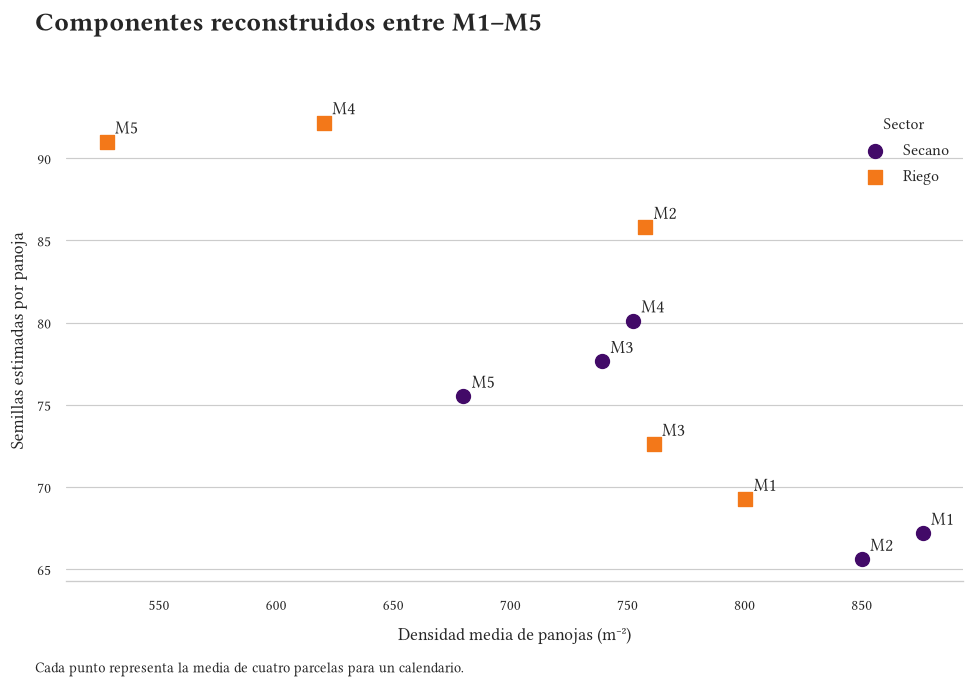

In [16]:
analysis.component_correlations()


### 5.6 Precisión técnica del peso de 100 semillas

,count,mean,std,min,25%,50%,75%,max
technical_cv_pct,48.0000,3.1740,1.5370,0.5650,2.3460,2.9940,4.1010,7.0920


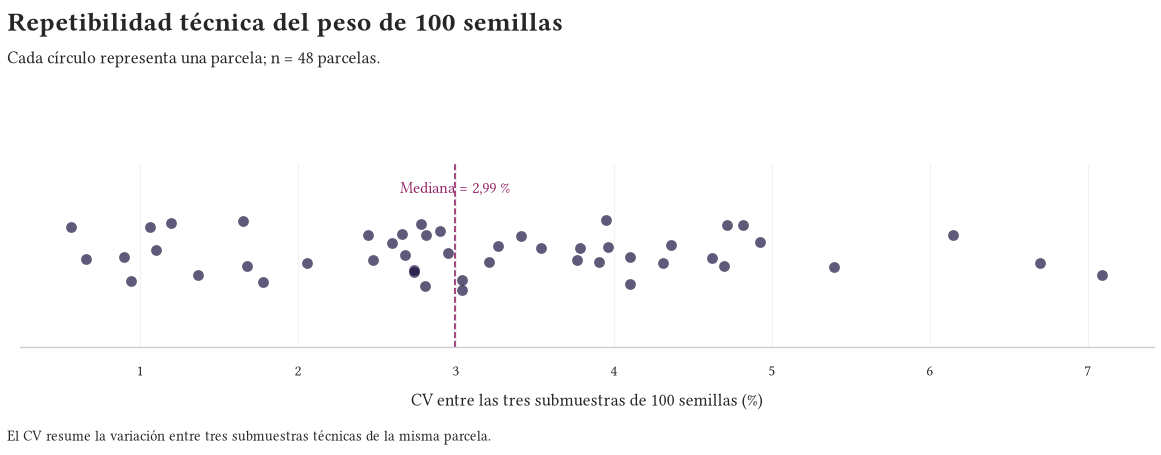

In [17]:
analysis.seed_weight_precision()


## 6. Diagnóstico de los modelos clásicos

Se examinan normalidad, homogeneidad y observaciones influyentes sin eliminar automáticamente registros. Con cuatro repeticiones por tratamiento, las pruebas formales tienen poca potencia; deben leerse junto con los gráficos y la sensibilidad.

In [18]:
analysis.model_diagnostics()


,outcome,label,sector,date,comparison,n,shapiro_p,levene_median_p,max_abs_studentized,max_cooks_d,cooks_4_over_n_count,iqr_flag_count,potential_flag
1,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Riego,2025-09-16,M1–M5,20,0.8290,0.7286,3.4701,0.5226,3,0,True
3,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Riego,2025-10-20,M1–M5,20,0.4063,0.9952,2.1647,0.2987,4,0,True
5,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Riego,2025-11-12,M1–M5,20,0.8006,0.6288,2.4238,0.3481,2,1,True
0,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Secano,2025-09-16,M1–M5,20,0.2364,0.0518,3.9123,0.5818,3,1,True
2,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Secano,2025-10-20,M1–M5,20,0.0567,0.5960,2.3167,0.3279,2,0,True
4,biomass_kg_ha_used,Biomasa aérea (kg MS ha⁻¹),Secano,2025-11-12,M1–M5,20,0.9146,0.6226,2.2474,0.3147,2,0,True
19,nni_revised,INN revisado,Riego,2025-09-16,M1–M5,20,0.9914,0.4823,2.3549,0.3352,2,1,True
21,nni_revised,INN revisado,Riego,2025-10-20,M1–M5,20,0.5933,0.2922,2.0760,0.2815,2,2,True
23,nni_revised,INN revisado,Riego,2025-11-12,M1–M5,20,0.3241,0.0408,2.2278,0.3109,1,0,True
18,nni_revised,INN revisado,Secano,2025-09-16,M1–M5,19,0.6472,0.6700,2.3372,0.3295,2,0,True


### 6.1 Diagnóstico gráfico del resultado primario

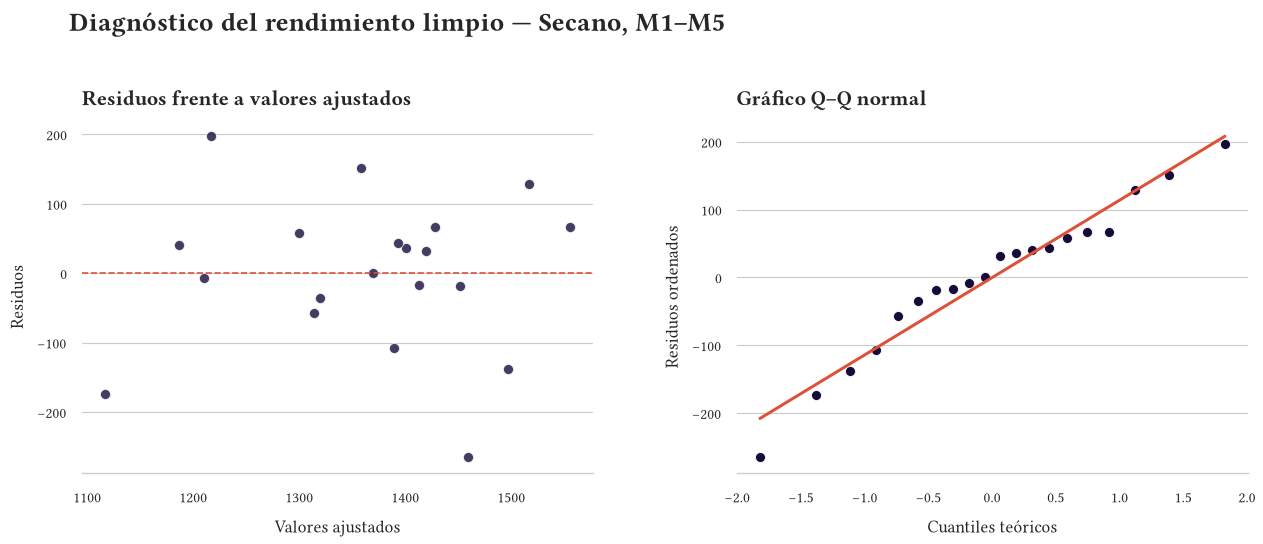

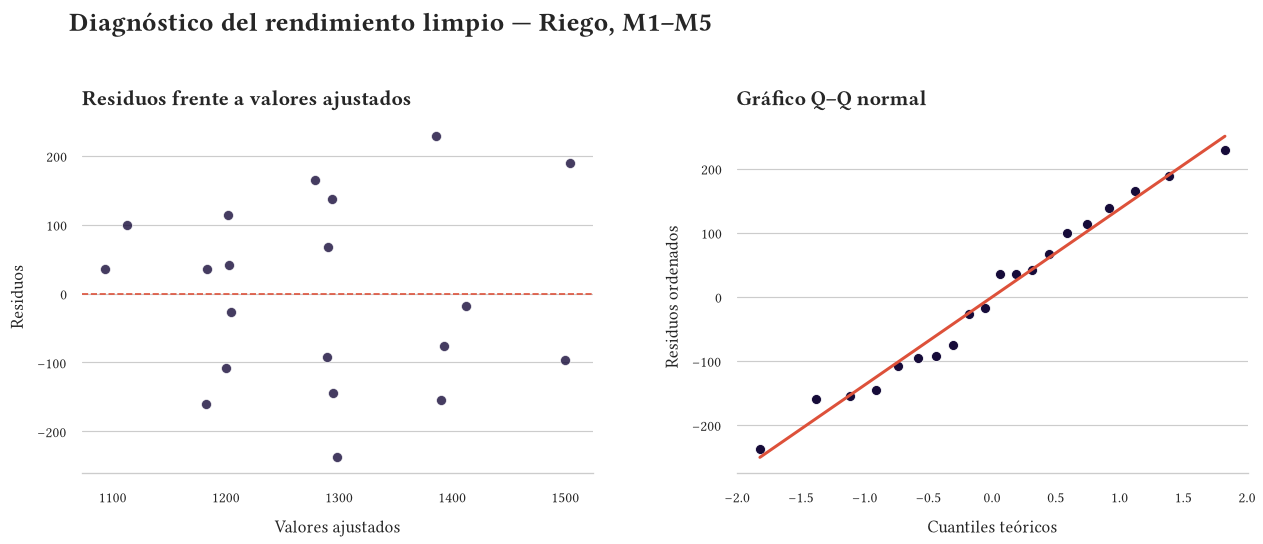

In [19]:
analysis.primary_residual_diagnostics()


## 7. Sensibilidad del dato faltante de N

La observación principal permanece ausente. La siguiente celda estima una celda faltante en un diseño de bloques completos al azar:

$$
\hat{x}=\frac{rB+tT-G}{(r-1)(t-1)},
$$

donde $r$ es el número de bloques, $t$ el número de tratamientos, $B$ el total observado del bloque, $T$ el total observado del tratamiento y $G$ el total general observado.

La sensibilidad se ejecuta en una copia del conjunto de datos y nunca reemplaza el dato observado.

In [20]:
analysis.missing_n_sensitivity()


,imputación DBCA
n_pct,2.4858
adf_pct,32.7409
ndf_pct,55.0156


,outcome,scenario,p_M1_M5
0,N en biomasa (%),observado,0.2518
1,N en biomasa (%),imputado,0.1534
2,N presente en biomasa aérea (kg N ha⁻¹),observado,0.0061
3,N presente en biomasa aérea (kg N ha⁻¹),imputado,0.0032
4,INN revisado,observado,0.0071
5,INN revisado,imputado,0.0033


## 8. Análisis conjunto descriptivo entre sectores

Para M1–M5 se ajusta:

$$
Y \sim momento \times sector + bloque(sector).
$$

La interacción describe si el patrón relativo de M1–M5 difiere entre **estos dos sectores**. El efecto principal del sector no se interpreta como un efecto causal del riego.

In [21]:
analysis.joint_sector_analysis()


,label,date_label,n,p_treatment,p_treatment_x_sector,p_sector
0,Biomasa aérea (kg MS ha⁻¹),16 sep,40,0.0000,0.0621,0.9837
1,Biomasa aérea (kg MS ha⁻¹),20 oct,40,0.0333,0.6917,0.6228
2,Biomasa aérea (kg MS ha⁻¹),12 nov,40,0.0044,0.8938,0.8317
3,N en biomasa (%),16 sep,39,0.0281,0.3135,0.7598
4,N en biomasa (%),20 oct,40,0.0001,0.0794,0.7864
5,N en biomasa (%),12 nov,40,0.0017,0.8367,0.4278
6,N presente en biomasa aérea (kg N ha⁻¹),16 sep,39,0.0000,0.4603,0.8040
7,N presente en biomasa aérea (kg N ha⁻¹),20 oct,40,0.7454,0.1013,0.7964
8,N presente en biomasa aérea (kg N ha⁻¹),12 nov,40,0.0240,0.4872,0.6635
9,INN revisado,16 sep,39,0.0000,0.4968,0.9685


## 9. Correlaciones exploratorias y extensión de auditoría

Primero se calculan las correlaciones de Pearson con las 24 parcelas de cada sector y con las 48 parcelas combinadas. Después se muestran dos extensiones:

1. correlación restringida a M1–M5;
2. correlación entre residuos después de ajustar tratamiento y bloque.

La segunda distingue la separación entre grupos de tratamiento de la asociación entre parcelas comparables. No convierte la correlación en causal. Las variables que contienen el rendimiento en su fórmula quedan marcadas como matemáticamente acopladas y toda la familia se etiqueta como exploratoria. Se informa FDR de Benjamini–Hochberg, no una colección de pruebas aisladas.

In [22]:
analysis.correlation_audit()


sector,Conjunto,Riego,Secano
variable,,,
Biomasa final,0.4560,0.2860,0.6260
Concentración de N,0.5520,0.5310,0.5650
Merma de limpieza*,-0.4510,-0.5200,-0.4150
N presente en biomasa aérea,0.6900,0.5830,0.7910
Panojas m⁻²,0.5310,0.4400,0.6060
Peso de mil semillas,0.1640,0.0440,0.2420
Semillas estimadas por panoja*,0.6930,0.7600,0.7580
Índice de cosecha*,0.7060,0.7940,0.6060


,variable,sector,raw_r,raw_p,M1_M5_r,M1_M5_p,adjusted_r,adjusted_p,adjusted_p_bh,inference_tier
0,Biomasa final,Secano,0.6259,0.0011,0.3763,0.1020,0.2929,0.1649,0.4946,exploratoria
1,Biomasa final,Riego,0.2860,0.1754,0.1832,0.4394,-0.1073,0.6179,0.9770,exploratoria
2,Concentración de N,Secano,0.5653,0.0040,0.0792,0.7398,-0.4034,0.0506,0.3036,exploratoria
3,Concentración de N,Riego,0.5305,0.0077,0.0689,0.7728,0.0161,0.9404,0.9770,exploratoria
4,N presente en biomasa aérea,Secano,0.7914,0.0000,0.4475,0.0479,0.0062,0.9770,0.9770,exploratoria
5,N presente en biomasa aérea,Riego,0.5832,0.0028,0.2111,0.3716,-0.0944,0.6608,0.9770,exploratoria


## 10. Análisis longitudinal con modelos mixtos

Para cada sector y variable se ajustan tres modelos por máxima verosimilitud, con intercepto aleatorio por parcela:

- **base:** `fecha + bloque`;
- **aditivo:** `fecha + tratamiento + bloque`;
- **completo:** `fecha × tratamiento + bloque`.

El código intenta todos los optimizadores configurados y conserva el ajuste **convergente con mayor log-verosimilitud**; un valor finito por sí solo ya no se acepta como éxito. Para biomasa y concentración de N M1–M5, la interacción tratamiento × fecha se calibra mediante un bootstrap paramétrico de 199 réplicas bajo el modelo reducido. Las pruebas asintóticas de N presente en biomasa e INN se mantienen únicamente como resultados derivados de apoyo. Se controla FDR dentro de las familias secundaria y de apoyo.

El resultado se estandariza antes del ajuste para mejorar la estabilidad numérica y se vuelve a expresar en sus unidades originales para las medias marginales. La biomasa también se reajusta en escala logarítmica y se compara la dispersión residual entre fechas. En varios modelos la varianza del intercepto aleatorio puede quedar en el límite cero; esto se informa explícitamente y aconseja no exagerar la complejidad longitudinal.

In [23]:
analysis.mixed_models()


,tier,outcomes,multiplicity
0,Primaria,Rendimiento limpio M1–M5,Contraste planificado; p sin ajuste
1,Secundaria,Biomasa aérea y concentración de N longitudinales,FDR de Benjamini-Hochberg en la familia
2,Apoyo,"N presente en biomasa, INN y componentes",FDR por familia; no evidencia independiente
3,Exploratoria/sensibilidad,"Correlaciones, EAN, productividad aparente del...",FDR para correlaciones; el resto descriptivo


,label,sector,comparison,inference_tier,n,plots,p_average_treatment,p_treatment_x_date_asymptotic,p_treatment_x_date_bootstrap,p_treatment_x_date,p_treatment_x_date_bh,interaction_p_method,p_global_trajectory,random_intercept_variance_z,random_effect_boundary,residual_sd_max_min_ratio,optimizer,optimizer_selection,converged
0,Biomasa aérea (kg MS ha⁻¹),Secano,M1–M5,secundaria_primitiva,60,20,0.0000,0.0746,0.2250,0.2250,0.3000,parametric_bootstrap,0.0000,0.0000,True,1.1917,powell,best_converged,True
1,Biomasa aérea (kg MS ha⁻¹),Secano,M0–M5,complementaria,72,24,0.0000,0.0432,NaN,0.0432,0.0432,asymptotic_lrt_support,0.0000,0.0000,True,1.1183,powell,best_converged,True
2,Biomasa aérea (kg MS ha⁻¹),Riego,M1–M5,secundaria_primitiva,60,20,0.0001,0.7863,0.9000,0.9000,0.9000,parametric_bootstrap,0.0037,0.0000,True,1.6665,cg,best_converged,True
3,Biomasa aérea (kg MS ha⁻¹),Riego,M0–M5,complementaria,72,24,0.0000,0.0212,NaN,0.0212,0.0283,asymptotic_lrt_support,0.0000,0.0024,False,2.0279,powell,best_converged,True
4,N en biomasa (%),Secano,M1–M5,secundaria_primitiva,59,20,0.3780,0.0088,0.0500,0.0500,0.1000,parametric_bootstrap,0.0165,0.0000,True,1.7625,powell,best_converged,True
5,N en biomasa (%),Secano,M0–M5,complementaria,71,24,0.0000,0.0000,NaN,0.0000,0.0000,asymptotic_lrt_support,0.0000,0.0000,True,1.6703,powell,best_converged,True
6,N en biomasa (%),Riego,M1–M5,secundaria_primitiva,60,20,0.0069,0.0000,0.0050,0.0050,0.0200,parametric_bootstrap,0.0000,0.0000,True,2.5414,powell,best_converged,True
7,N en biomasa (%),Riego,M0–M5,complementaria,72,24,0.0000,0.0000,NaN,0.0000,0.0000,asymptotic_lrt_support,0.0000,0.0000,True,2.5371,powell,best_converged,True
8,N presente en biomasa aérea (kg N ha⁻¹),Secano,M1–M5,apoyo_derivado,59,20,0.0015,0.0004,NaN,0.0004,0.0004,asymptotic_lrt_support,0.0000,0.0000,True,2.2956,powell,best_converged,True
9,N presente en biomasa aérea (kg N ha⁻¹),Secano,M0–M5,complementaria,71,24,0.0000,0.0001,NaN,0.0001,0.0001,asymptotic_lrt_support,0.0000,0.0000,True,2.0641,powell,best_converged,True


**Sensibilidad de biomasa a escala original versus logarítmica:**

,sector,response_scale,p_treatment_x_date_asymptotic,p_treatment_x_date_bootstrap,bootstrap_successful,residual_sd_max_min_ratio,random_effect_boundary,optimizer,converged
0,Secano,original,0.0746,0.2250,199,1.1917,True,powell,True
1,Secano,log,0.0001,0.0100,199,1.5597,True,powell,True
2,Riego,original,0.7863,0.9000,199,1.6665,True,cg,True
3,Riego,log,0.5684,0.7500,199,1.4176,True,powell,True


### 10.1 Medias marginales y datos observados del modelo longitudinal

Las dos figuras principales se restringen a las variables primitivas: **biomasa aérea** y **concentración de N en biomasa**, cada una en dos paneles (secano y riego). Las variables derivadas N presente en biomasa e INN pasan a una figura técnica de apoyo. Los valores de p se resumen fuera de los paneles para no convertir la figura en una cuadrícula de pruebas.

Las observaciones individuales se superponen con las medias marginales del modelo completo, promediadas sobre los cuatro bloques. El 16 de septiembre M5 todavía había recibido solo 100 kg N ha⁻¹ experimentales; esa diferencia transitoria de dosis debe acompañar la interpretación.

,outcome,sector,date_label,early_minus_late,se,ci_low,ci_high,z,p_normal
0,Biomasa aérea (kg MS ha⁻¹),Secano,16 sep,"4,642.3750",797.0495,"3,080.1580","6,204.5920",5.8245,0.0000
1,Biomasa aérea (kg MS ha⁻¹),Secano,20 oct,"1,883.7500",797.0495,321.5330,"3,445.9670",2.3634,0.0181
2,Biomasa aérea (kg MS ha⁻¹),Secano,12 nov,"2,496.8553",797.0495,934.6383,"4,059.0723",3.1326,0.0017
3,Biomasa aérea (kg MS ha⁻¹),Riego,16 sep,"1,693.8750",588.6447,540.1314,"2,847.6186",2.8776,0.0040
4,Biomasa aérea (kg MS ha⁻¹),Riego,20 oct,"2,082.0000",588.6447,928.2564,"3,235.7436",3.5369,0.0004
5,Biomasa aérea (kg MS ha⁻¹),Riego,12 nov,"2,115.5855",588.6447,961.8420,"3,269.3291",3.5940,0.0003
6,N en biomasa (%),Secano,16 sep,0.1950,0.0889,0.0208,0.3692,2.1943,0.0282
7,N en biomasa (%),Secano,20 oct,-0.2433,0.0843,-0.4086,-0.0781,-2.8868,0.0039
8,N en biomasa (%),Secano,12 nov,-0.1213,0.0843,-0.2865,0.0439,-1.4390,0.1501
9,N en biomasa (%),Riego,16 sep,0.4394,0.0895,0.2640,0.6148,4.9109,0.0000


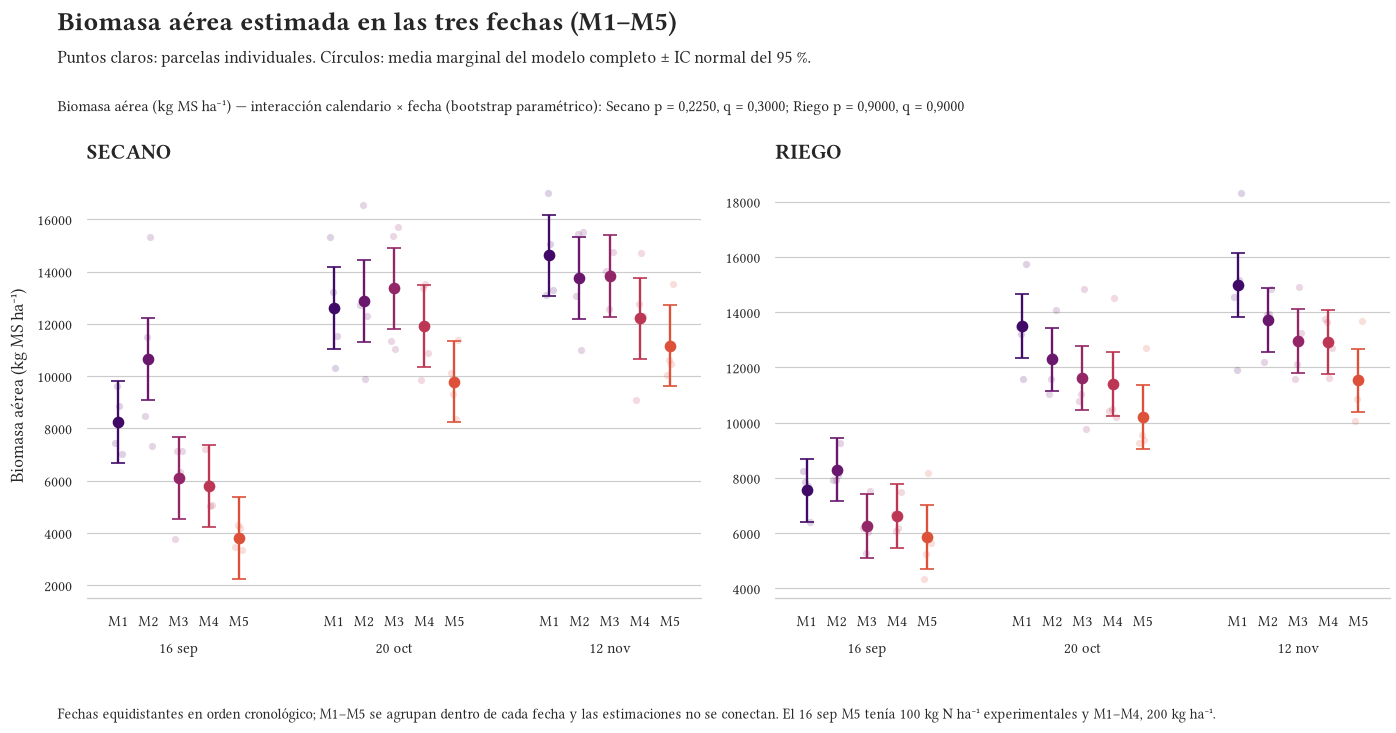

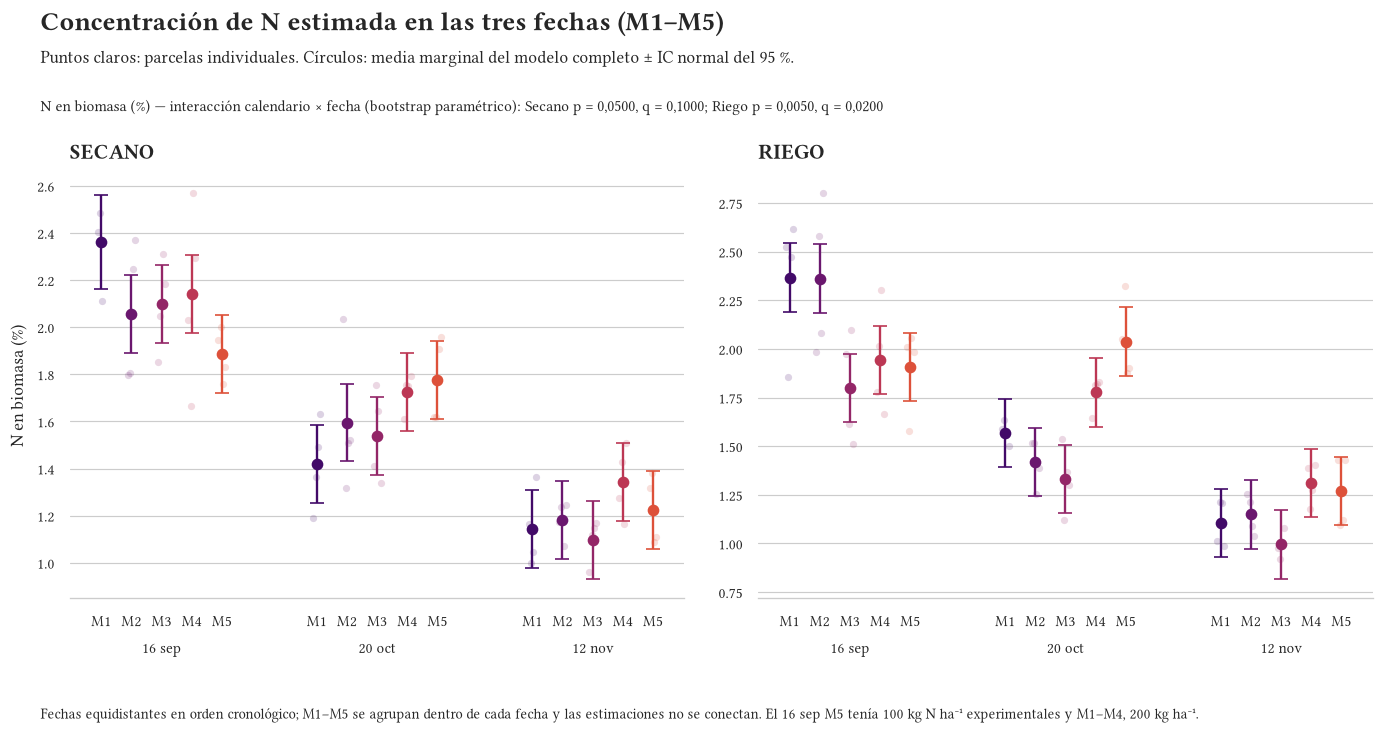

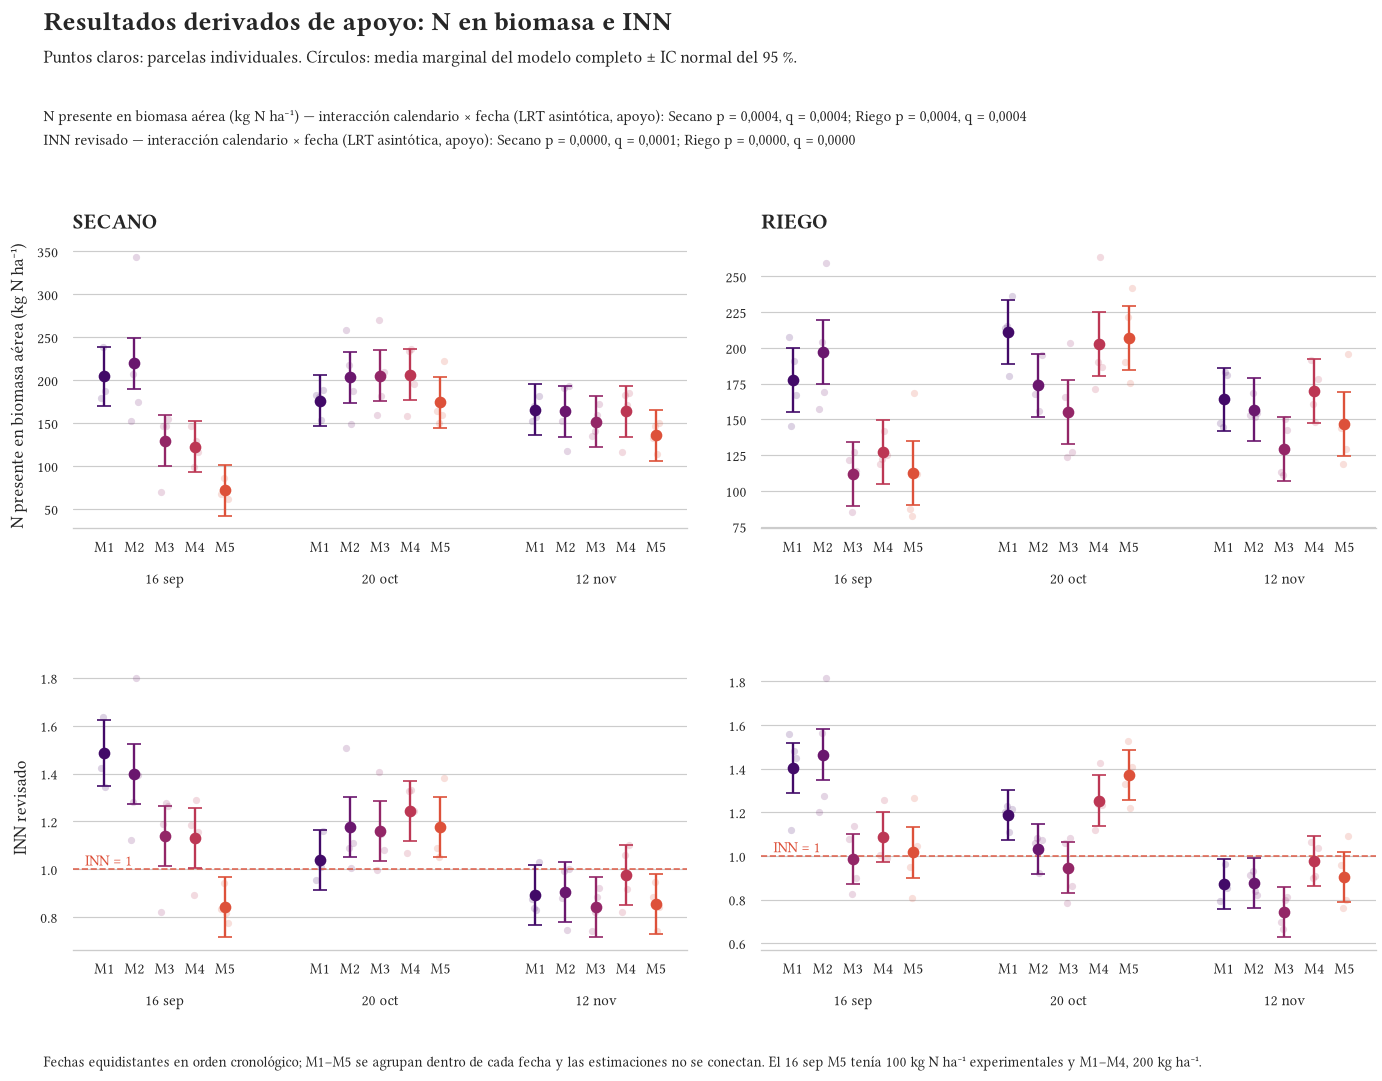

In [24]:
analysis.mixed_estimates()


### 10.2 Sensibilidad de septiembre excluyendo M5

El 16 de septiembre M5 aún no había recibido la segunda aplicación. La comparación M1–M5 describe correctamente los calendarios completos, pero en esa fecha también incluye una diferencia transitoria de dosis acumulada. Como sensibilidad, se muestra M1–M4, donde todos habían completado los 200 kg N ha⁻¹.

In [25]:
analysis.september_sensitivity()


,outcome,sector,p_M1_M4,cv_pct
0,Biomasa aérea (kg MS ha⁻¹),Secano,0.0256,26.1114
1,Biomasa aérea (kg MS ha⁻¹),Riego,0.0172,10.6970
2,N en biomasa (%),Secano,0.4096,11.9926
3,N en biomasa (%),Riego,0.1192,17.1190
4,N presente en biomasa aérea (kg N ha⁻¹),Secano,0.0749,31.2769
5,N presente en biomasa aérea (kg N ha⁻¹),Riego,0.0097,19.8783
6,INN revisado,Secano,0.1185,16.1967
7,INN revisado,Riego,0.0278,17.2140


## 11. Selección sugerida de figuras para la tesis

No todas las figuras del cuaderno deberían pasar al cuerpo principal. La tabla siguiente separa las figuras que sostienen el argumento científico de las que funcionan mejor como respaldo técnico. El futuro anexo probabilístico probablemente sustituya o complemente el forest plot clásico de contrastes de rendimiento.

In [26]:
analysis.figure_manifest()


,archivo,ubicación sugerida,función,prioridad
0,figura_01_cronograma_y_n_acumulado,Métodos — cuerpo principal,"Define los calendarios, el cierre del pastoreo...",Esencial
1,figura_02_aportes_mensuales_de_agua,Sitio y manejo — cuerpo principal,Muestra la distribución temporal de precipitac...,Alta
2,figura_03_rendimiento_dos_preguntas,Resultados — cuerpo principal,Separa la respuesta a N adicional de la compar...,Esencial
3,figura_04_trayectorias_biomasa_aerea,Resultados — cuerpo principal,Resume la variable primitiva de biomasa con da...,Esencial
4,figura_05_trayectorias_concentracion_n,Resultados — cuerpo principal,Resume la variable primitiva de concentración ...,Esencial
5,anexo_trayectorias_n_biomasa_e_inn,Anexo técnico,Presenta N presente en biomasa e INN como resu...,Complementaria
6,figura_06_componentes_del_rendimiento,Resultados — cuerpo principal o síntesis,Muestra los componentes con observaciones e in...,Alta
7,anexo_contrastes_rendimiento,Anexo o discusión de incertidumbre,Cuantifica la respuesta frente a M0 y cuánto d...,Alta hasta disponer del anexo probabilístico
8,anexo_trayectorias_observadas_*,Anexo,Conserva la comparación descriptiva M0–M5 sin ...,Complementaria


## 12. Síntesis automática de resultados

Esta sección resume resultados ejecutados, no valores copiados manualmente.

In [27]:
analysis.automatic_summary()


- **Secano:** rendimiento M1–M5 p = 0.4287; M0–M5 p = < 0.0001; CV M1–M5 = 10.2 % y CV M0–M5 = 12.1 %.
- **Riego:** rendimiento M1–M5 p = 0.1759; M0–M5 p = < 0.0001; CV M1–M5 = 12.9 % y CV M0–M5 = 13.5 %.

**Pruebas longitudinales M1–M5 (interacción tratamiento × fecha):**
- Biomasa aérea (kg MS ha⁻¹), Secano: p = 0.2250 (bootstrap paramétrico; q BH = 0.3000); varianza de parcela en el límite.
- Biomasa aérea (kg MS ha⁻¹), Riego: p = 0.9000 (bootstrap paramétrico; q BH = 0.9000); varianza de parcela en el límite.
- N en biomasa (%), Secano: p = 0.0500 (bootstrap paramétrico; q BH = 0.1000); varianza de parcela en el límite.
- N en biomasa (%), Riego: p = 0.0050 (bootstrap paramétrico; q BH = 0.0200); varianza de parcela en el límite.
- N presente en biomasa aérea (kg N ha⁻¹), Secano: p = 0.0004 (LRT asintótica de apoyo; q BH = 0.0004); varianza de parcela en el límite.
- N presente en biomasa aérea (kg N ha⁻¹), Riego: p = 0.0004 (LRT asintótica de apoyo; q BH = 0.0004); varianza de parcela en el límite.
- INN revisado, Secano: p = < 0.0001 (LRT asintótica de apoyo; q BH = < 0.0001); varianza de parcela en el límite.
- INN revisado, Riego: p = < 0.0001 (LRT asintótica de apoyo; q BH = < 0.0001); varianza de parcela en el límite.

**Sensibilidad de escala de la biomasa:**
- Secano: escala original p = 0.2250; escala logarítmica p = 0.0100.
- Riego: escala original p = 0.9000; escala logarítmica p = 0.7500.
La diferencia entre escalas en secano impide presentar esa interacción de biomasa como una conclusión robusta a la especificación.

**Lectura recomendada:** los ANOVA por fecha describen momentos concretos; el modelo longitudinal evalúa directamente si las trayectorias cambian con el calendario. La ausencia de una diferencia de rendimiento entre M1–M5 no debe traducirse en equivalencia exacta, y las diferencias entre sectores siguen siendo descriptivas.

## 13. Exportación de tablas y figuras

Se exportan resultados derivados, no una copia alterada del libro original.

In [28]:
analysis.export_artifacts()


Tablas exportadas en: /Users/agustinsellanes/Repos/festuca_probabilistic_analysis/festuca_thesis_analysis_outputs
 - anova_conjunto_entre_sectores.csv
 - anova_por_fecha_y_sector.csv
 - anova_variables_finales.csv
 - aportes_mensuales_de_agua.csv
 - contrastes_rendimiento_clasicos.csv
 - contrastes_temprano_menos_tardio.csv
 - correlaciones_extension_auditoria.csv
 - correlaciones_tesis.csv
 - diagnosticos_modelos_clasicos.csv
 - indicadores_derivados_descriptivos.csv
 - jerarquia_inferencial.csv
 - modelos_longitudinales_mixtos.csv
 - registros_materia_seca_a_verificar.csv
 - seleccion_figuras_tesis.csv
 - sensibilidad_escala_biomasa.csv
 - sensibilidad_materia_seca_150_152.csv
Figuras exportadas en: /Users/agustinsellanes/Repos/festuca_probabilistic_analysis/festuca_thesis_figures
 - anexo_contrastes_rendimiento.pdf
 - anexo_contrastes_rendimiento.png
 - anexo_trayectorias_n_biomasa_e_inn.pdf
 - anexo_trayectorias_n_biomasa_e_inn.png
 - anexo_trayectorias_observadas_biomass_kg_ha_use

## 14. Alcance y límites

- La parcela es la unidad experimental del momento de aplicación dentro de cada sector.
- Secano y riego suplementario ocupan un único sector cada uno; el cuaderno no estima un efecto causal general del riego.
- Las mediciones de junio son descriptivas y no permiten ajuste basal por parcela.
- El dato faltante de N no se imputa en el análisis principal.
- Los registros de materia seca 150 y 152 requieren verificación primaria. El valor registrado es principal y las políticas cociente/exclusión son sensibilidades explícitas.
- El número estimado de semillas por panoja, el índice de cosecha, la merma, la eficiencia agronómica y la productividad aparente del agua comparten componentes algebraicos con otras variables y no generan evidencia independiente por ser columnas separadas.
- El bootstrap paramétrico calibra la interacción longitudinal de biomasa y concentración de N; las LRT asintóticas de desenlaces derivados son solo apoyo.
- Los análisis exploratorios se identifican como tales y se informa FDR dentro de familias, pero el ajuste multiplicativo no convierte una asociación en causal.
- Los resultados longitudinales deben acompañarse con magnitudes, intervalos, gráficos y sensibilidades de escala y de calidad de datos.